<a href="https://colab.research.google.com/github/sagarkakkar03/Data-science/blob/main/DataCleaning%26Analytics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [24]:
import pandas as pd
import numpy as np

In [53]:
df = pd.read_csv('customer_data_final.csv')
df.head()

,CustomerID,Age,Gender,AnnualIncome,SpendingScore,PurchaseCount,City,CustomerSatisfactionScore,LastPurchaseAmount
0,1,66,Female,81476,3,21,Bangalore,47,10
1,2,29,Female,64811,53,20,Chennai,43,19
2,3,75,Female,187280,23,5,Mumbai,57,9
3,4,35,Female,171222,53,5,Mumbai,60,15
4,5,38,Female,91180,37,47,Pune,41,30


In [54]:
df.duplicated().any()

np.False_

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 200 non-null    int64  
 1   Age                        190 non-null    float64
 2   Gender                     190 non-null    object 
 3   AnnualIncome               189 non-null    float64
 4   SpendingScore              190 non-null    float64
 5   PurchaseCount              190 non-null    float64
 6   City                       191 non-null    object 
 7   CustomerSatisfactionScore  200 non-null    float64
 8   LastPurchaseAmount         200 non-null    float64
dtypes: float64(6), int64(1), object(2)
memory usage: 14.2+ KB


In [ ]:
df.isnull().sum()

,0
CustomerID,0
Age,10
Gender,10
AnnualIncome,11
SpendingScore,10
PurchaseCount,10
City,9
CustomerSatisfactionScore,0
LastPurchaseAmount,0


In [5]:
pd.set_option('display.float_format', '{:.0f}'.format)

In [ ]:
df.describe()

,CustomerID,Age,AnnualIncome,SpendingScore,PurchaseCount,CustomerSatisfactionScore,LastPurchaseAmount
count,200,190,189,190,190,200,200
mean,100,47,161510,52,23,55,27
std,58,22,721622,44,14,33,60
min,1,-10,-5000,-50,0,23,0
25%,51,28,58413,25,10,45,6
50%,100,47,108461,52,24,51,15
75%,150,66,160507,78,35,57,28
max,200,150,9999999,500,49,302,562


In [ ]:
df['Gender'].value_counts()

,count
Gender,
Female,97
Male,84
Other,9


In [55]:
df['Age'].fillna('Missing', inplace = True)

/tmp/ipython-input-651/1913371507.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna('Missing', inplace = True)
/tmp/ipython-input-651/1913371507.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'Missing' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df['Age'].fillna('Missing', inplace = True)


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 200 non-null    int64  
 1   Age                        200 non-null    object 
 2   Gender                     190 non-null    object 
 3   AnnualIncome               189 non-null    float64
 4   SpendingScore              190 non-null    float64
 5   PurchaseCount              190 non-null    float64
 6   City                       191 non-null    object 
 7   CustomerSatisfactionScore  200 non-null    float64
 8   LastPurchaseAmount         200 non-null    float64
dtypes: float64(5), int64(1), object(3)
memory usage: 14.2+ KB


In [56]:
gender_dummies = pd.get_dummies(df['Gender'])

In [57]:
df.drop(columns =['Gender'], inplace=True)

In [58]:
df_final = pd.concat([df, gender_dummies], axis = 1)
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 200 non-null    int64  
 1   Age                        200 non-null    object 
 2   AnnualIncome               189 non-null    float64
 3   SpendingScore              190 non-null    float64
 4   PurchaseCount              190 non-null    float64
 5   City                       191 non-null    object 
 6   CustomerSatisfactionScore  200 non-null    float64
 7   LastPurchaseAmount         200 non-null    float64
 8   Female                     200 non-null    bool   
 9   Male                       200 non-null    bool   
 10  Other                      200 non-null    bool   
dtypes: bool(3), float64(5), int64(1), object(2)
memory usage: 13.2+ KB


In [59]:
df_final.loc[df_final['AnnualIncome'] < 0, 'AnnualIncome'] = df_final['AnnualIncome'].mean()

In [60]:
df_final['Age'] = pd.to_numeric(df_final['Age'], errors='coerce')

In [61]:
df_final.loc[df_final['SpendingScore'] < 0, 'SpendingScore'] = df_final['SpendingScore'].median()
df_final.loc[df_final['Age'] < 0, 'Age'] = df_final['Age'].median()


In [62]:
df_final['Age'].fillna(df_final['Age'].median(), inplace=True)

/tmp/ipython-input-651/69964.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['Age'].fillna(df_final['Age'].median(), inplace=True)


In [63]:
df_final['AnnualIncome'].fillna(df_final['AnnualIncome'].mean(), inplace = True)
df_final['SpendingScore'].fillna(df_final['SpendingScore'].mean(), inplace = True)

/tmp/ipython-input-651/3920196836.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['AnnualIncome'].fillna(df_final['AnnualIncome'].mean(), inplace = True)
/tmp/ipython-input-651/3920196836.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[c

In [29]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 200 non-null    int64  
 1   Age                        200 non-null    float64
 2   AnnualIncome               200 non-null    float64
 3   SpendingScore              200 non-null    float64
 4   PurchaseCount              190 non-null    float64
 5   City                       191 non-null    object 
 6   CustomerSatisfactionScore  200 non-null    float64
 7   LastPurchaseAmount         200 non-null    float64
 8   Female                     200 non-null    bool   
 9   Male                       200 non-null    bool   
 10  Other                      200 non-null    bool   
dtypes: bool(3), float64(6), int64(1), object(1)
memory usage: 13.2+ KB


In [64]:
df_final['PurchaseCount'].fillna(df_final['PurchaseCount'].mean(), inplace=True)
df_final['City'].fillna(df_final['City'].mode()[0], inplace=True)

/tmp/ipython-input-651/247734655.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_final['PurchaseCount'].fillna(df_final['PurchaseCount'].mean(), inplace=True)
/tmp/ipython-input-651/247734655.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col

In [65]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   CustomerID                 200 non-null    int64  
 1   Age                        200 non-null    float64
 2   AnnualIncome               200 non-null    float64
 3   SpendingScore              200 non-null    float64
 4   PurchaseCount              200 non-null    float64
 5   City                       200 non-null    object 
 6   CustomerSatisfactionScore  200 non-null    float64
 7   LastPurchaseAmount         200 non-null    float64
 8   Female                     200 non-null    bool   
 9   Male                       200 non-null    bool   
 10  Other                      200 non-null    bool   
dtypes: bool(3), float64(6), int64(1), object(1)
memory usage: 13.2+ KB


In [66]:
df_final = df_final[df_final['Age'] <= 100]

In [42]:
df_final['City'].value_counts()

,count
City,
Delhi,55
Bangalore,38
Pune,37
Mumbai,35
Chennai,34


<Axes: ylabel='AnnualIncome'>

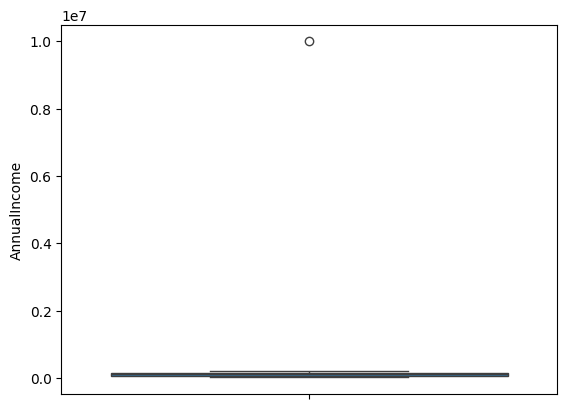

In [43]:
import seaborn as sns
sns.boxplot(df_final['AnnualIncome'])

<Axes: ylabel='SpendingScore'>

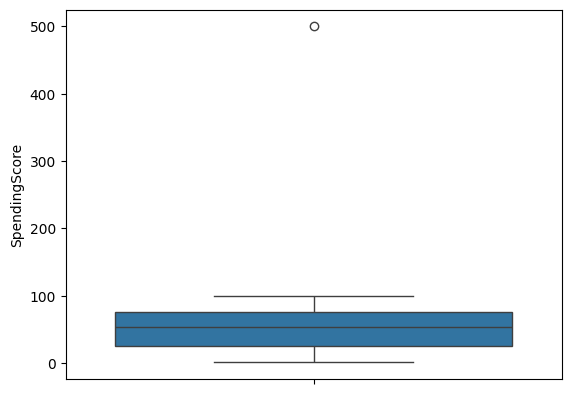

In [45]:
sns.boxplot(df_final['SpendingScore'])

In [67]:
def remove_outliers(dataframe: pd.DataFrame, column_name: str):
  IQR = dataframe[column_name].quantile(0.75) - dataframe[column_name].quantile(0.25)
  lower_limit = dataframe[column_name].quantile(0.25) - 1.5*IQR
  upper_limit = dataframe[column_name].quantile(0.75) + 1.5*IQR
  return dataframe[(dataframe[column_name] < upper_limit) & (dataframe[column_name] > lower_limit)]

In [68]:
df_final = remove_outliers(df_final, 'AnnualIncome')
df_final = remove_outliers(df_final, 'SpendingScore')

<Axes: ylabel='AnnualIncome'>

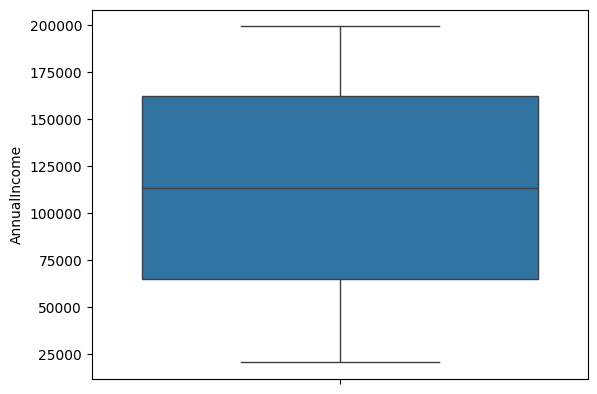

In [69]:
sns.boxplot(df_final['AnnualIncome'])

<Axes: ylabel='SpendingScore'>

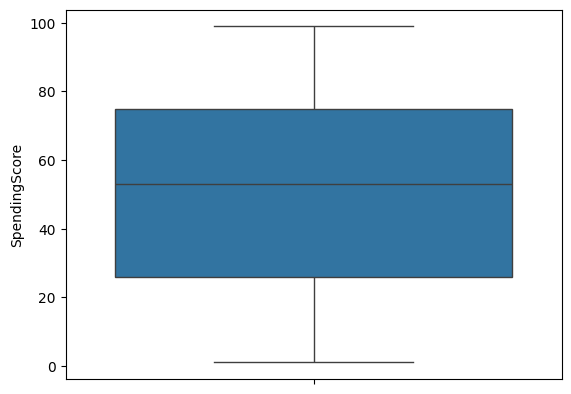

In [70]:
sns.boxplot(df_final['SpendingScore'])

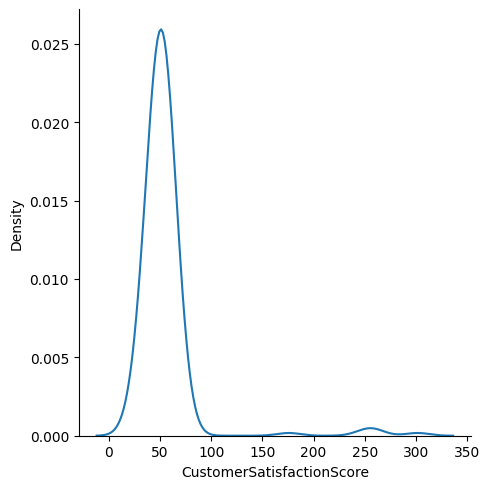

In [72]:
sns.displot(df_final['CustomerSatisfactionScore'], kind = 'kde')

In [73]:
df_final = df_final[df_final['CustomerSatisfactionScore'] > 130]

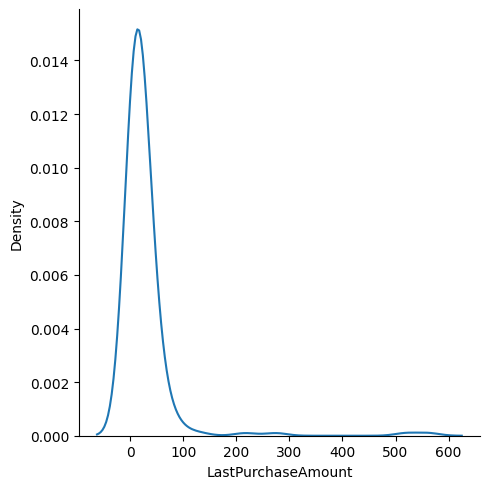

In [75]:
sns.displot(df_final['LastPurchaseAmount'], kind = 'kde')

In [76]:
df_final = df_final[df_final['LastPurchaseAmount'] > 120]

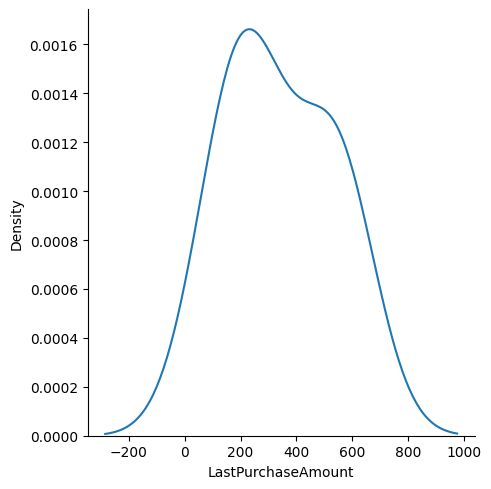

In [77]:
sns.displot(df_final['LastPurchaseAmount'], kind = 'kde')

In [86]:
top_5_cities_by_spending = df_final.groupby('City')['SpendingScore'].mean()

In [88]:
top_5_cities_by_spending.sort_values(ascending=False)

,SpendingScore
City,
Bangalore,92
Chennai,57
Mumbai,51
Delhi,48


In [94]:
df_final.groupby('City')['AnnualIncome'].mean()

,AnnualIncome
City,
Bangalore,113396
Chennai,80566
Delhi,103508
Mumbai,146174


In [101]:
df_final.groupby('Female')['PurchaseCount'].mean()

,PurchaseCount
Female,
False,26
True,40


In [105]:
df_final.groupby('City')['CustomerSatisfactionScore'].sum()

,CustomerSatisfactionScore
City,
Bangalore,59
Chennai,52
Delhi,97
Mumbai,50


In [110]:
df_final['CustomerSatisfactionScore'].corr(df_final['SpendingScore'])

np.float64(0.46115203892221046)

In [112]:
df_final['LastPurchaseAmount'].sort_values(ascending=False)

,LastPurchaseAmount
36,562
73,520
109,275
45,217
106,130


In [113]:
bins = [0, 29, 55, float('inf')]
labels = ['Young (<30)', 'Middle (30-55)', 'Senior (>55)']
df_final['AgeGroup'] = pd.cut(df_final['Age'], bins=bins, labels=labels, right=True)

age_group_spending = df_final.groupby('AgeGroup', observed=False)['SpendingScore'].mean().sort_values(ascending=False)

print("Average Spending Score by Age Group:")
display(age_group_spending)

highest_spending_age_group = age_group_spending.index[0]
highest_spending_score = age_group_spending.iloc[0]
print(f"\nThe age group with the highest spending score is: {highest_spending_age_group} with an average of {highest_spending_score:.0f}")

Average Spending Score by Age Group:


/tmp/ipython-input-651/2615493357.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  age_group_spending = df_final.groupby('AgeGroup')['SpendingScore'].mean().sort_values(ascending=False)


,SpendingScore
AgeGroup,
Young (<30),74
Senior (>55),49
Middle (30-55),NaN



The age group with the highest spending score is: Young (<30) with an average of 74
